## This notebook solves the antimeridian problem when plotting geojson paths

In this next cell, some testing is conducted by using the unwrap linestring method for a cable system that crosses the antimeridian and it is observed that the paths no longer have the horizontal line and the path crossing the antimeridian is plotted in a logical manner. We note that the geojson files for each cable system are outputs of the cable routing algorithm that is available upon request.

Skipping field path_nodes: unsupported OGR type: 5
C:\Users\Dean\AppData\Local\Temp\ipykernel_4816\451408089.py:24: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'LineString':


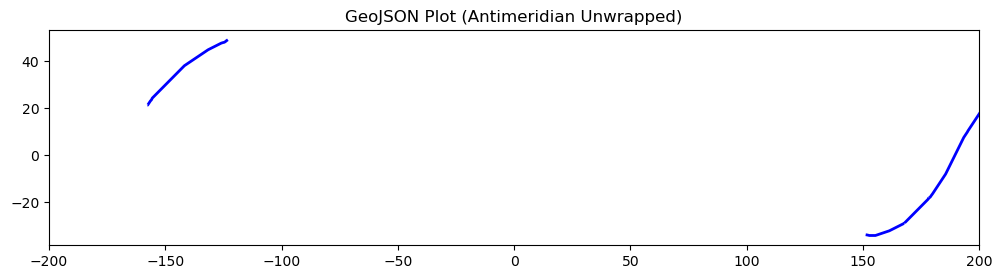

EPSG:4326


In [3]:
import geopandas as gpd
from shapely.geometry import LineString, MultiLineString
import matplotlib.pyplot as plt

def unwrap_linestring(line):
    coords = list(line.coords)
    if not coords:
        return line
    new_coords = [coords[0]]
    offset = 0
    prev_lon = coords[0][0]
    for lon, lat in coords[1:]:
        dlon = lon + offset - prev_lon
        if dlon < -180:
            offset += 360
        elif dlon > 180:
            offset -= 360
        new_lon = lon + offset
        new_coords.append((new_lon, lat))
        prev_lon = new_lon
    return LineString(new_coords)

def unwrap_geometry(geom):
    if geom.type == 'LineString':
        return unwrap_linestring(geom)
    elif geom.type == 'MultiLineString':
        return MultiLineString([unwrap_linestring(line) for line in geom.geoms])
    else:
        return geom

# Load your GeoJSON
gdf = gpd.read_file('paths_1984.3_1_1984_1997.geojson')

# Unwrap all geometries
gdf['geometry'] = gdf['geometry'].apply(unwrap_geometry)

# Plot with longitude limits set to "unwrap" view
fig, ax = plt.subplots(figsize=(12, 6))
gdf.plot(ax=ax, linewidth=2, edgecolor='blue')
ax.set_xlim(-200, 200)  # Show the "unwrapped" longitude range
ax.set_title('GeoJSON Plot (Antimeridian Unwrapped)')
plt.show()
print(gdf.crs)


Here we test it and plot on a world map

Skipping field path_nodes: unsupported OGR type: 5
C:\Users\Dean\AppData\Local\Temp\ipykernel_4816\2855739649.py:25: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'LineString':
C:\Users\Dean\AppData\Local\Temp\ipykernel_4816\2855739649.py:35: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'Polygon':
C:\Users\Dean\AppData\Local\Temp\ipykernel_4816\2855739649.py:39: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  elif geom.type == 'MultiPolygon':


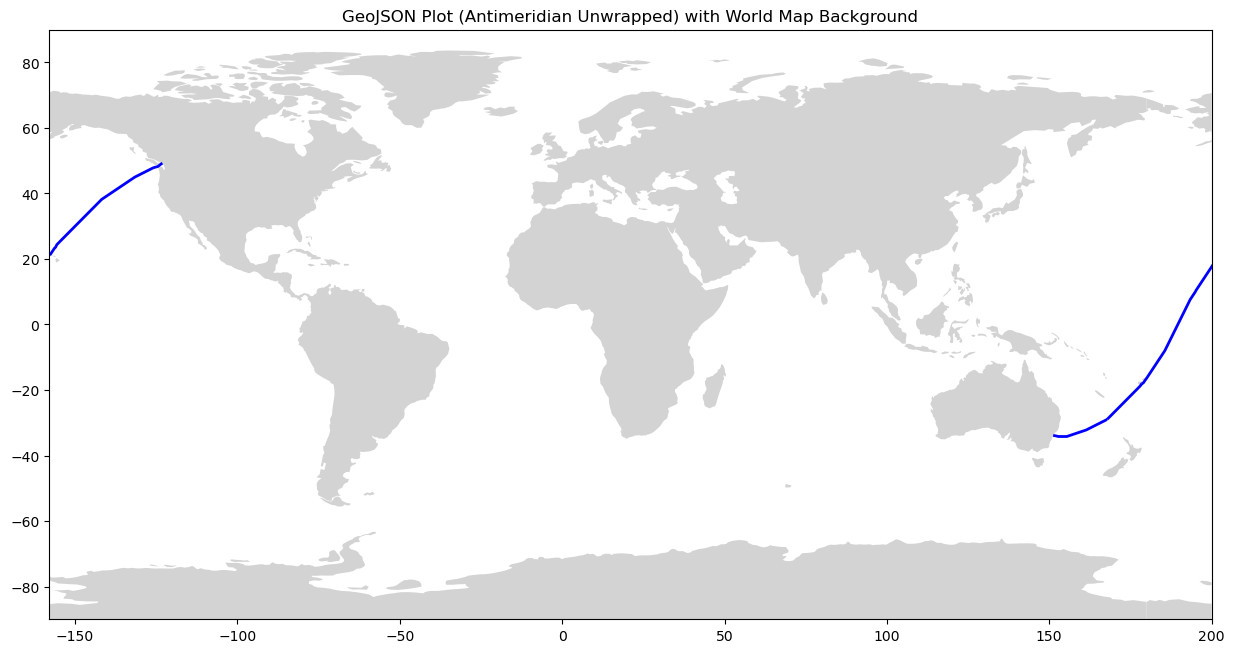

In [5]:
import geopandas as gpd
from shapely.geometry import LineString, MultiLineString, box, Polygon, MultiPolygon
import matplotlib.pyplot as plt
import numpy as np

def unwrap_linestring(line):
    coords = list(line.coords)
    if not coords:
        return line
    new_coords = [coords[0]]
    offset = 0
    prev_lon = coords[0][0]
    for lon, lat in coords[1:]:
        dlon = lon + offset - prev_lon
        if dlon < -180:
            offset += 360
        elif dlon > 180:
            offset -= 360
        new_lon = lon + offset
        new_coords.append((new_lon, lat))
        prev_lon = new_lon
    return LineString(new_coords)

def unwrap_geometry(geom):
    if geom.type == 'LineString':
        return unwrap_linestring(geom)
    elif geom.type == 'MultiLineString':
        return MultiLineString([unwrap_linestring(line) for line in geom.geoms])
    else:
        return geom

def shift_longitude(geom, shift):
    def shift_coords(coords):
        return [(lon + shift, lat) for lon, lat in coords]
    if geom.type == 'Polygon':
        exterior = shift_coords(geom.exterior.coords)
        interiors = [shift_coords(interior.coords) for interior in geom.interiors]
        return Polygon(exterior, interiors)
    elif geom.type == 'MultiPolygon':
        return MultiPolygon([shift_longitude(part, shift) for part in geom.geoms])
    elif geom.type == 'LineString':
        return LineString(shift_coords(geom.coords))
    elif geom.type == 'MultiLineString':
        return MultiLineString([shift_longitude(line, shift) for line in geom.geoms])
    else:
        return geom

# Load your GeoJSON
gdf = gpd.read_file('paths_1984.3_1_1984_1997.geojson')
gdf['geometry'] = gdf['geometry'].apply(unwrap_geometry)

# Load world map from public URL (Natural Earth countries)
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/physical/ne_110m_land.zip")

# Create bounding box for longitude between -180 and -160
bbox = box(-180, -90, -160, 90)

# Clip world map geometries to the bounding box
world_clipped = world.copy()
world_clipped['geometry'] = world_clipped.geometry.intersection(bbox)
world_clipped = world_clipped[~world_clipped.is_empty]

# Shift world map by +360 degrees longitude
world_shifted = world_clipped.copy()
world_shifted['geometry'] = world_shifted['geometry'].apply(lambda geom: shift_longitude(geom, 360))

# Plot
fig, ax = plt.subplots(figsize=(15, 15))
world.plot(ax=ax, color='lightgray', edgecolor='none', linewidth=0.5, zorder=0)
world_shifted.plot(ax=ax, color='lightgray', edgecolor='none', linewidth=0.5, zorder=0)
gdf.plot(ax=ax, linewidth=2, edgecolor='blue', zorder=1)

ax.set_xlim(-158, 200)
ax.set_ylim(-90, 90)
ax.set_title('GeoJSON Plot (Antimeridian Unwrapped) with World Map Background')
plt.show()


Next we include all relevant cable systems and plot the global network accordingly for 2024.

C:\Users\Dean\AppData\Local\Temp\ipykernel_18808\2227904920.py:36: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'Polygon':
C:\Users\Dean\AppData\Local\Temp\ipykernel_18808\2227904920.py:40: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  elif geom.type == 'MultiPolygon':
Skipping field path_nodes: unsupported OGR type: 5
C:\Users\Dean\AppData\Local\Temp\ipykernel_18808\2227904920.py:26: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'LineString':
Skipping field path_nodes: unsupported OGR type: 5
C:\Users\Dean\AppData\Local\Temp\ipykernel_18808\2227904920.py:26: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. 

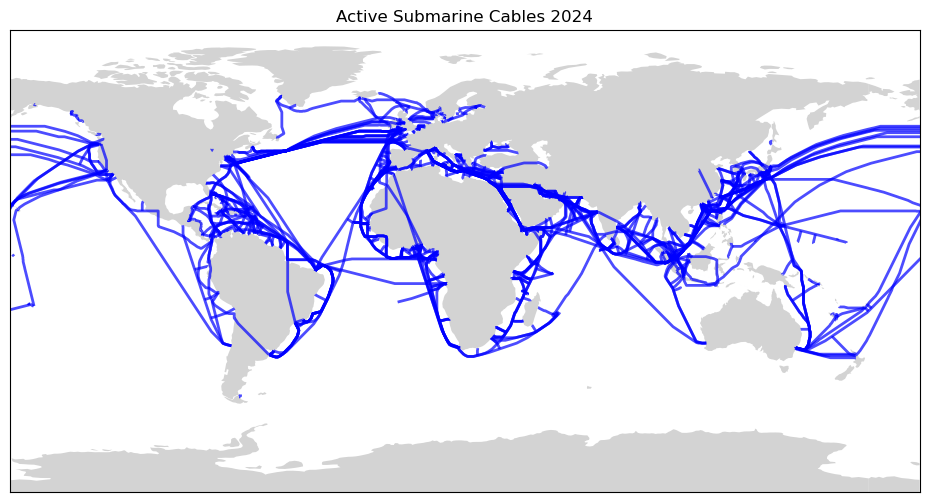

In [1]:
import geopandas as gpd
from shapely.geometry import LineString, MultiLineString, box, Polygon, MultiPolygon
import matplotlib.pyplot as plt
import numpy as np
import os

def unwrap_linestring(line):
    coords = list(line.coords)
    if not coords:
        return line
    new_coords = [coords[0]]
    offset = 0
    prev_lon = coords[0][0]
    for lon, lat in coords[1:]:
        dlon = lon + offset - prev_lon
        if dlon < -180:
            offset += 360
        elif dlon > 180:
            offset -= 360
        new_lon = lon + offset
        new_coords.append((new_lon, lat))
        prev_lon = new_lon
    return LineString(new_coords)

def unwrap_geometry(geom):
    if geom.type == 'LineString':
        return unwrap_linestring(geom)
    elif geom.type == 'MultiLineString':
        return MultiLineString([unwrap_linestring(line) for line in geom.geoms])
    else:
        return geom

def shift_longitude(geom, shift):
    def shift_coords(coords):
        return [(lon + shift, lat) for lon, lat in coords]
    if geom.type == 'Polygon':
        exterior = shift_coords(geom.exterior.coords)
        interiors = [shift_coords(interior.coords) for interior in geom.interiors]
        return Polygon(exterior, interiors)
    elif geom.type == 'MultiPolygon':
        return MultiPolygon([shift_longitude(part, shift) for part in geom.geoms])
    elif geom.type == 'LineString':
        return LineString(shift_coords(geom.coords))
    elif geom.type == 'MultiLineString':
        return MultiLineString([shift_longitude(line, shift) for line in geom.geoms])
    else:
        return geom

# Load world map from public URL (Natural Earth countries)
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/physical/ne_110m_land.zip")

# Create bounding box for longitude between -180 and -160
bbox = box(-180, -90, -160, 90)

# Clip world map geometries to the bounding box
world_clipped = world.copy()
world_clipped['geometry'] = world_clipped.geometry.intersection(bbox)
world_clipped = world_clipped[~world_clipped.is_empty]

# Shift world map by +360 degrees longitude
world_shifted = world_clipped.copy()
world_shifted['geometry'] = world_shifted['geometry'].apply(lambda geom: shift_longitude(geom, 360))

# Folder containing GeoJSON files
folder_path = 'C:/Users/Dean/Downloads/IfW/New folder (5)'

# List all GeoJSON files in the folder
geojson_files = [f for f in os.listdir(folder_path) if f.endswith('.geojson')]

# Prepare the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each GeoJSON file
for file in geojson_files:
    file_path = os.path.join(folder_path, file)
    gdf = gpd.read_file(file_path)
    gdf['geometry'] = gdf['geometry'].apply(unwrap_geometry)
    #print(gdf.crs)
    gdf.plot(ax=ax, linewidth=2, edgecolor='blue', alpha=0.7, label=file)

world.plot(ax=ax, color='lightgray', edgecolor='none', linewidth=0.5, zorder=0)
world_shifted.plot(ax=ax, color='lightgray', edgecolor='none', linewidth=0.5, zorder=0)

ax.set_xlim(-159, 200)
ax.set_ylim(-90, 90)
ax.set_title('Active Submarine Cables 2024')
ax.set_xticks([])
ax.set_yticks([])
plt.show()